In [1]:
# Cell 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

In [2]:
# Cell 2: Load Dataset

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# Summary statistics
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
# Missing values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
# Remove duplicates
df = df.drop_duplicates()

In [8]:
# Cell 4: Outlier Detection (Corrected IQR Method)

# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Filter out outliers only from numeric columns
df = df[~((numeric_df < (Q1 - 1.5 * IQR)) | 
          (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

df.shape

(198, 5)

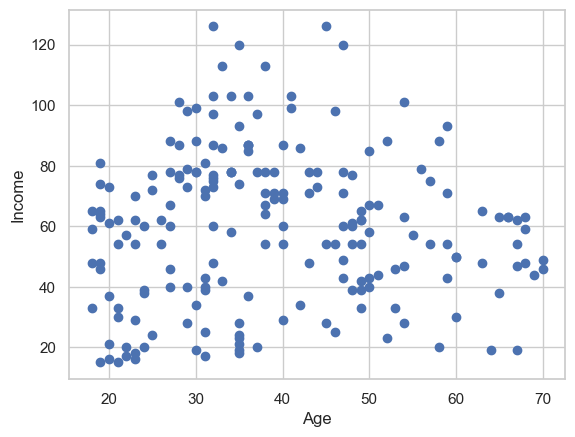

In [9]:
# Age vs Income
plt.scatter(df['Age'], df['Annual Income (k$)'])
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

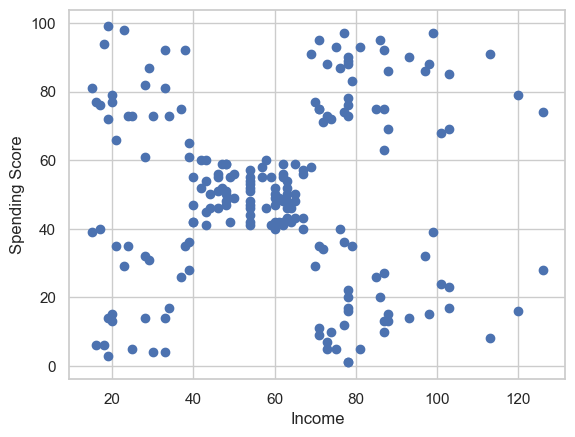

In [10]:
# Income vs Spending
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

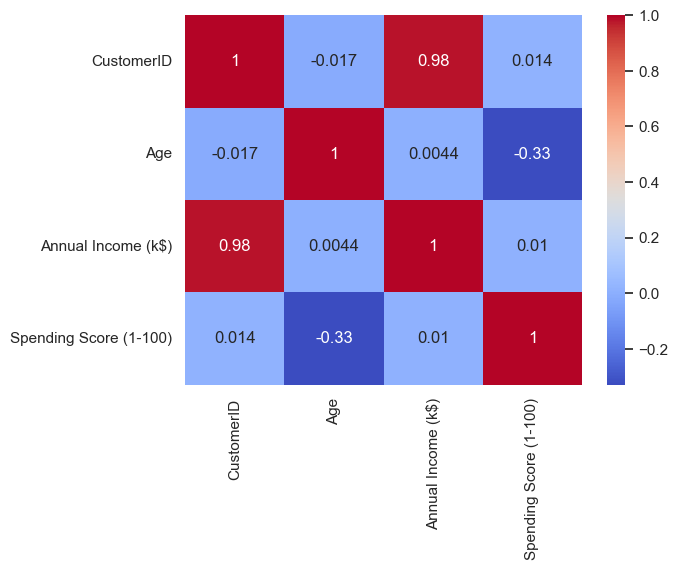

In [11]:
# Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [12]:
# Encode Gender
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

# Feature selection
X = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\akshi\AppData\Local\Temp\ipykernel_21132\2845647752.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})


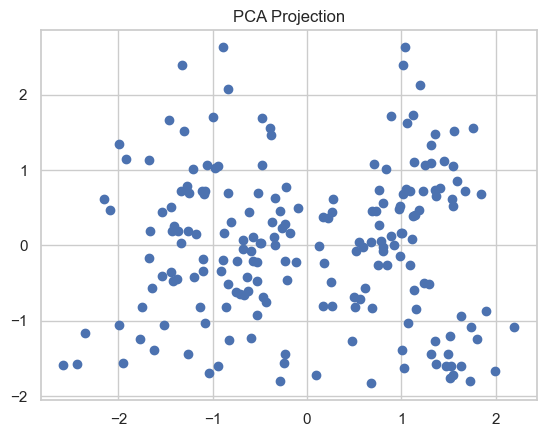

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Projection")
plt.show()

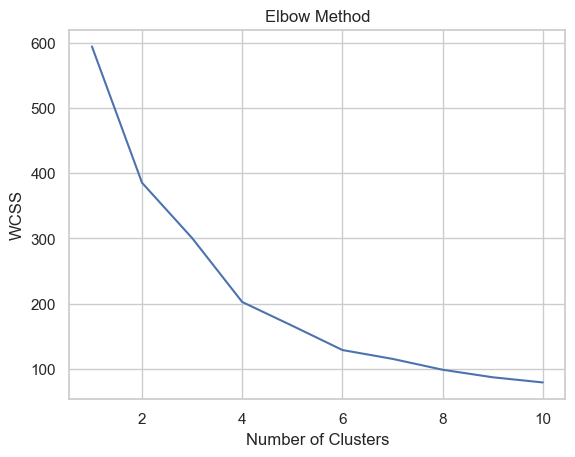

In [14]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [15]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = clusters

C:\Users\akshi\AppData\Local\Temp\ipykernel_21132\2205654273.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['KMeans_Cluster'] = clusters


In [16]:
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.4120846422078083


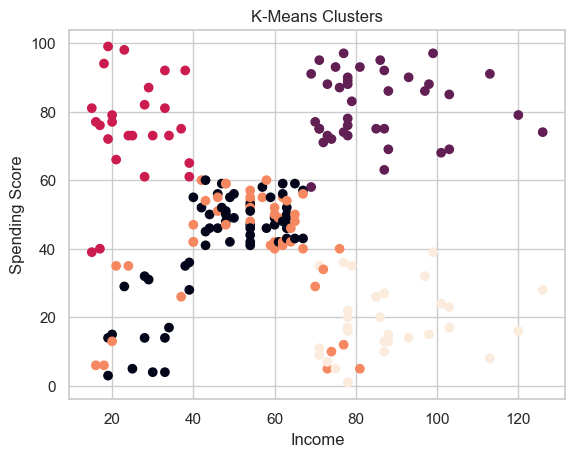

In [17]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=clusters)
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clusters")
plt.show()

In [18]:
df.groupby('KMeans_Cluster').mean()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,,,
0,68.775862,0.568966,55.275862,47.620690,41.706897
1,160.025641,0.564103,32.948718,84.794872,81.487179
2,22.320000,0.600000,25.480000,25.480000,75.440000
3,85.630435,0.586957,26.869565,54.043478,41.326087
4,165.800000,0.500000,44.800000,88.200000,18.500000


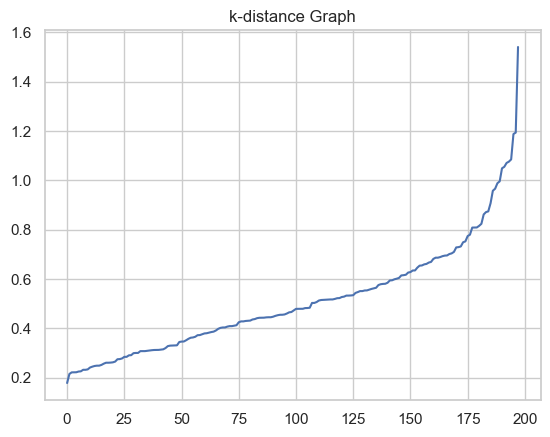

In [19]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])
plt.plot(distances)
plt.title("k-distance Graph")
plt.show()

In [20]:
db = DBSCAN(eps=0.5, min_samples=5)
db_clusters = db.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_clusters

C:\Users\akshi\AppData\Local\Temp\ipykernel_21132\3260706014.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DBSCAN_Cluster'] = db_clusters


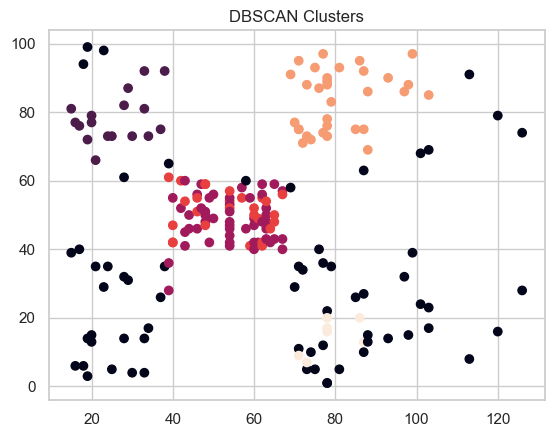

In [21]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=db_clusters)
plt.title("DBSCAN Clusters")
plt.show()

In [22]:
abnormal = df[df['DBSCAN_Cluster'] == -1]
abnormal

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,DBSCAN_Cluster
0,1,0,19,15,39,2,-1
2,3,1,20,16,6,3,-1
4,5,1,31,17,40,2,-1
6,7,1,35,18,6,3,-1
7,8,1,23,18,94,2,-1
...,...,...,...,...,...,...,...
193,194,1,38,113,91,1,-1
194,195,1,47,120,16,4,-1
195,196,1,35,120,79,1,-1
196,197,1,45,126,28,4,-1


In [23]:
print("Total Customers:", len(df))
print("K-Means Clusters:", df['KMeans_Cluster'].nunique())
print("Abnormal Customers (DBSCAN Noise):", len(abnormal))

Total Customers: 198
K-Means Clusters: 5
Abnormal Customers (DBSCAN Noise): 64
